# A quick introduction to Linear Regression in Python

> **Overview**
> 
> This brief practical is intended to provide you with a starting point to experiment with some aspects of linear regression. 
> 
> Don't worry if you don't understand all of the code here; it's the ideas that are important: What happens when we **train** or **fit** our model is that parameters are adjusted to try to minimise a **cost function**.
>

First, we'll load in a dataset that we can use to show linear regression. Seaborn is a visualisation library for Python, but it also includes some convenient "demo" datasets that are useful for visualising techniques like linear regression.

Here we import the Seaborn library, then we load the dataset into a varaible `tips`. We then look at the first part of this dataset with the `head` method.

In [5]:
import seaborn as sns

tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


This is our training data. In what follows we'll be using the first two columns of this table only.

Next we'll import `matplotlib`, a common plotting library. 

In [6]:
import matplotlib.pyplot as plt 

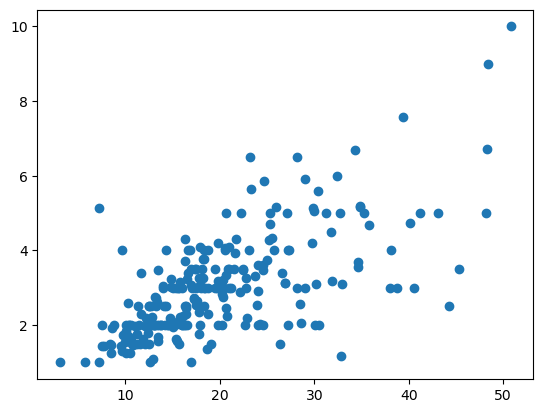

In [7]:
plt.scatter(tips['total_bill'],tips['tip'])

Before we use **Machine Learning** to get the computer to build a model, experiment to see if you can find a _slope_ and _intercept_ for a line that you think fits this data well "visually". Run the cell below, and then you can move the sliders below to set values of slope and intercept.

In [8]:
from ipywidgets import interact, FloatSlider

def plot_line(slope=1.0, intercept=0.0):
    plt.figure(figsize=(6, 6))
    plt.scatter(tips.iloc[:,0:1],tips.iloc[:,1:2])
    plt.plot(x, slope * x + intercept, linewidth=2, color='red')
    plt.xlim(0, 50)
    plt.ylim(0, 10)
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"y = {slope:.2f}x + {intercept:.2f}")
    plt.show()

x=tips.iloc[:,0:1]

interact(
    plot_line,
    slope=FloatSlider(value=1, min=-5, max=5, step=0.01, description="Slope"),
    intercept=FloatSlider(value=0, min=-5, max=5, step=0.1, description="Intercept")
);

interactive(children=(FloatSlider(value=1.0, description='Slope', max=5.0, min=-5.0, step=0.01), FloatSlider(v…

Although it's possible to get a fairly good fit by looking at the plot, it would be helpful if we could get a measurement for how good our fit is.

This is sometimes referred to as the **cost function**.

The cost function is something that we're free to choose. For linear regression, the normal choice of the cost function is a sum of the squares of the distances between the points and the line (which is why it's sometimes referred to as "least squres regression").

The code below is modifed to calculate the calue of the cost function and to print it below the graph. Try moving the sliders again to see if the values you chose for the slope and intercept do indeed make this cost function as low as possible. 

In [9]:
def plot_line(slope=1.0, intercept=0.0):
    plt.figure(figsize=(6, 6))
    plt.scatter(tips.iloc[:,0:1],tips.iloc[:,1:2])
    plt.plot(x, slope * x + intercept, linewidth=2, color='red')
    plt.xlim(0, 50)
    plt.ylim(0, 10)
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"y = {slope:.2f}x + {intercept:.2f}")
    plt.show()
    
    ypred=slope*x+intercept
    costfunction=((tips.iloc[:,1:2].values-ypred.values)**2).sum()
    
    print("value of cost function:", costfunction)

x=tips.iloc[:,0:1]

interact(
    plot_line,
    slope=FloatSlider(value=1, min=-5, max=5, step=0.01, description="Slope"),
    intercept=FloatSlider(value=0, min=-5, max=5, step=0.1, description="Intercept")
);

interactive(children=(FloatSlider(value=1.0, description='Slope', max=5.0, min=-5.0, step=0.01), FloatSlider(v…

Now we're going to use Machine Learning to find the best fit. We'll use linear regression to find the slope and the intercept (the "parameters") which "minimise the cost function".

We import `LinearRegression` from _scikit-learn_, a popular library for machine learning in Python. (Find out more at https://scikit-learn.org/).

In [10]:
from sklearn.linear_model import LinearRegression

And we "**train** the model" (or "**fit** the model to") the training data: 

In [11]:
reg=LinearRegression().fit(tips.iloc[:,0:1],tips.iloc[:,1:2]) # Note that fit expects you to pass in slices from a dataframe and not series

In [12]:
reg.coef_

array([[0.10502452]])

In [13]:
reg.intercept_

array([0.92026961])

Hopefully you'll see that these numbers are fairly close to the values you found manually above (although you'll be limited by the precision of the sliders in the widget, of course).

And taking a step back, if you think about what this means, this makes sense. The slope of 0.1 implies an average tip of about 10%.

----


In [15]:
# feel free to experiment further in this notebook!
# type ?LinearRegression to view the documentation, or visit https://scikit-learn.org/

In [16]:
?LinearRegression

Init signature:
LinearRegression(
    *,
    fit_intercept=True,
    copy_X=True,
    tol=1e-06,
    n_jobs=None,
    positive=False,
)
Docstring:     
Ordinary least squares Linear Regression.

LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
to minimize the residual sum of squares between the observed targets in
the dataset, and the targets predicted by the linear approximation.

Parameters
----------
fit_intercept : bool, default=True
    Whether to calculate the intercept for this model. If set
    to False, no intercept will be used in calculations
    (i.e. data is expected to be centered).

copy_X : bool, default=True
    If True, X will be copied; else, it may be overwritten.

tol : float, default=1e-6
    The precision of the solution (`coef_`) is determined by `tol` which
    specifies a different convergence criterion for the `lsqr` solver.
    `tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` when
    fitting on sparse training da

---
## Acknoweldgements & Reuse

Notebook created by Adam Carter, EPCC, The University of Edinburgh
&copy; 2026 The University of Edinburgh
You are welcome to reuse this notebook and its contents under the terms of CC BY 4.0
